# Re:Mind — Qwen2.5-7B-Instruct 파인튜닝

## 실행 전 체크리스트
- [ ] 런타임 유형: **A100 GPU** (런타임 → 런타임 유형 변경)
- [ ] Google Drive에 `remind_finetune/final_train.jsonl` 업로드 완료

## Step 1. 패키지 설치

In [1]:
%%capture
!pip install -q numpy==1.26.4
!pip install -q transformers==4.44.0
!pip install -q peft==0.12.0
!pip install -q trl==0.10.1
!pip install -q bitsandbytes --upgrade
!pip install -q accelerate==0.33.0
!pip install -q datasets==2.21.0
!pip install -q huggingface_hub==0.23.2
!pip install -q triton
import IPython
IPython.Application.instance().kernel.do_shutdown(True)

## Step 2. GPU 확인

In [1]:
import torch
print(f'GPU: {torch.cuda.get_device_name(0)}')
print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB')
if 'A100' in torch.cuda.get_device_name(0):
    print('A100 확인')
else:
    print('A100이 아닙니다. 런타임 유형을 변경해주세요.')

GPU: NVIDIA A100-SXM4-40GB
VRAM: 39.5 GB
A100 확인


## Step 3. Google Drive 마운트

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
DATA_PATH  = '/content/drive/MyDrive/remind_finetune/phq9_report_v3_train.jsonl'
OUTPUT_DIR = '/content/drive/MyDrive/remind_finetune/qwen_finetuned'
os.makedirs(OUTPUT_DIR, exist_ok=True)

if os.path.exists(DATA_PATH):
    size = os.path.getsize(DATA_PATH) / 1024**2
    print(f'데이터 파일 확인: {size:.1f} MB')
else:
    print(f'파일 없음: {DATA_PATH}')

Mounted at /content/drive
파일 없음: /content/drive/MyDrive/remind_finetune/phq9_report_v3_train.jsonl


## Step 4. 데이터 로드

In [9]:
import json
import random
from datasets import Dataset

samples = []
with open(DATA_PATH, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if line:
            samples.append(json.loads(line))

print(f'총 샘플 수: {len(samples)}개')

sample = random.choice(samples)
output = json.loads(sample['messages'][2]['content'])
print(f'출력 미리보기: {output["output"][:100]}...')

총 샘플 수: 10000개
출력 미리보기: 주요 증상: 환자는 주된 감정으로 '일상'을(를) 보고하였으며, PHQ-9 총점 7점으로 '경미한위험 (가벼운 우울)' 수준에 해당함. 주요 호소 증상은 식욕 변화, 부정적 인식,...


## Step 5. 데이터셋 분리

In [10]:
random.seed(42)
random.shuffle(samples)

n_val = max(100, int(len(samples) * 0.05))
val_data = samples[:n_val]
trn_data = samples[n_val:]

print(f'train: {len(trn_data)}개')
print(f'val:   {len(val_data)}개')

train_dataset = Dataset.from_list(trn_data)
val_dataset   = Dataset.from_list(val_data)

train: 9500개
val:   500개


## Step 6. 모델 로드 (QLoRA 4-bit)

In [11]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

MODEL_NAME = 'Qwen/Qwen2.5-7B-Instruct'
print(f'모델 로드 중: {MODEL_NAME} (5~10분 소요)')

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = 'right'

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map='auto',
    trust_remote_code=True,
)
model = prepare_model_for_kbit_training(model)
print('모델 로드 완료')

모델 로드 중: Qwen/Qwen2.5-7B-Instruct (5~10분 소요)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model-00003-of-00004.safetensors:   0%|          | 0.00/3.86G [00:00<?, ?B/s]

model-00004-of-00004.safetensors:   0%|          | 0.00/3.56G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

모델 로드 완료


## Step 7. LoRA 설정

In [12]:
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=['q_proj','k_proj','v_proj','o_proj','gate_proj','up_proj','down_proj'],
    lora_dropout=0.05,
    bias='none',
    task_type='CAUSAL_LM',
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 40,370,176 || all params: 7,655,986,688 || trainable%: 0.5273


## Step 8. 데이터 포맷 변환

In [13]:
def format_sample(sample):
    text = tokenizer.apply_chat_template(
        sample['messages'],
        tokenize=False,
        add_generation_prompt=False,
    )
    return {'text': text}

train_dataset = train_dataset.map(format_sample, num_proc=2)
val_dataset   = val_dataset.map(format_sample,   num_proc=2)
print('포맷 변환 완료')
print(train_dataset[0]['text'][:200])

Map (num_proc=2):   0%|          | 0/9500 [00:00<?, ? examples/s]

Map (num_proc=2):   0%|          | 0/500 [00:00<?, ? examples/s]

포맷 변환 완료
<|im_start|>system
당신은 앱 사용자의 1~2주치 생활 로그와 챗봇이 수집한 PHQ-9 슬롯 분석 데이터를 바탕으로, 정신건강의학과 의사가 진료에 활용할 수 있는 전문적인 임상 요약 리포트를 생성하는 AI입니다. 반드시 JSON 형식 {"output": "..."}으로만 응답하세요.<|im_end|>
<|im_start|>user
{"diar


## Step 9. 학습 실행 (약 3~5시간)

In [19]:
from transformers import TrainingArguments
from trl import SFTTrainer
import torch

# 재귀 방지
if not hasattr(torch, '_original_load'):
    torch._original_load = torch.load

def patched_torch_load(*args, **kwargs):
    kwargs['weights_only'] = False
    return torch._original_load(*args, **kwargs)
torch.load = patched_torch_load

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=3,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=8,
    learning_rate=2e-4,
    fp16=False,
    bf16=True,
    logging_steps=100,
    eval_strategy='steps',
    eval_steps=500,
    save_strategy='steps',
    save_steps=500,
    save_total_limit=2,
    load_best_model_at_end=True,
    warmup_ratio=0.05,
    lr_scheduler_type='cosine',
    report_to='none',
)

trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    dataset_text_field='text',
    max_seq_length=2048,
    packing=False,
)

print('학습 시작')
trainer.train(resume_from_checkpoint='/content/drive/MyDrive/remind_finetune/qwen_finetuned/checkpoint-8442')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_deprecation.py:100: FutureWarning: Deprecated argument(s) used in '__init__': dataset_text_field, max_seq_length. Will not be supported from version '1.0.0'.

Deprecated positional argument(s) used in SFTTrainer, please use the SFTConfig to set these arguments instead.
  warnings.warn(message, FutureWarning)
/usr/local/lib/python3.12/dist-packages/trl/trainer/sft_trainer.py:283: UserWarning: You passed a `max_seq_length` argument to the SFTTrainer, the value you passed will override the one in the `SFTConfig`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/trl/trainer/sft_trainer.py:321: UserWarning: You passed a `dataset_text_field` argument to the SFTTrainer, the value you passed will override the one in the `SFTConfig`.
  warnings.warn(


Map:   0%|          | 0/9500 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

학습 시작


Step,Training Loss,Validation Loss


TrainOutput(global_step=8442, training_loss=0.0, metrics={'train_runtime': 0.2053, 'train_samples_per_second': 138839.072, 'train_steps_per_second': 8666.481, 'total_flos': 1.1441111851946349e+19, 'train_loss': 0.0, 'epoch': 1.9998223485521407})

## Step 10. 모델 저장

In [15]:
model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
print(f'모델 저장 완료: {OUTPUT_DIR}')

모델 저장 완료: /content/drive/MyDrive/remind_finetune/qwen_finetuned


## Step 11. 추론 테스트

In [16]:
test_input = {
    "diary_logs": [
        {
            "date": "2026-04-21",
            "emotion": 2,
            "sleepStart": "02:30",
            "sleepEnd": "06:00",
            "sleepHours": "3시간 30분",
            "tookMedicine": True,
            "medicineReaction": "복약 후에도 기분 개선 없음",
            "diary": "오늘도 아무것도 하기 싫었다. 밥도 못 먹었다."
        }
    ],
    "phq9_analysis": {
        "total_score": 18,
        "risk_level": "중등도위험",
        "phq9_slots": [
            {"item_no": 1, "symptom": "흥미/즐거움 저하", "score": 3, "evidence": "아무것도 하기 싫다고 반복 언급"},
            {"item_no": 2, "symptom": "기분 저하", "score": 3, "evidence": "매일 우울감 호소"},
            {"item_no": 3, "symptom": "수면 장애", "score": 3, "evidence": "평균 수면 3.5시간"},
            {"item_no": 9, "symptom": "자해/자살 사고", "score": 0, "evidence": "관련 발언 없음"}
        ]
    }
}

messages = [
    {
        "role": "system",
        "content": "당신은 앱 사용자의 생활 로그와 PHQ-9 분석 데이터를 바탕으로 의사용 임상 요약 리포트를 생성하는 AI입니다."
    },
    {
        "role": "user",
        "content": json.dumps(test_input, ensure_ascii=False)
    }
]

model.eval()
input_text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
inputs = tokenizer(input_text, return_tensors='pt').to('cuda')

with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=512,
        temperature=0.7,
        do_sample=True,
        pad_token_id=tokenizer.eos_token_id,
    )

response = tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
print('[파인튜닝 모델 출력]')
print(response)

[파인튜닝 모델 출력]
**주요 증상:** 내담자는 중등도 위험 수준의 우울증을 보이며, 일상적인 활동에 대한 흥미가 저하되어 있으며, 기분이 지속적으로 우울하다고 언급하였다. 수면 패턴은 불규칙하며 평균 수면 시간이 3.5시간으로 충분하지 않게 나타나고 있다. 복약 후에도 기분 개선이 없었으며, 이러한 상태는 내담자의 정서적 안정에 부정적인 영향을 미치고 있다.

**위험 요인:** 내담자는 흥미와 즐거움의 저하, 기분 저하, 수면 장애와 같은 주요 우울 증상을 보이고 있으며, 이는 일상생활에서의 어려움과 관련이 있다. 특히, 수면 시간의 부족은 내담자의 전반적인 기분에 부정적인 영향을 미칠 가능성이 있다. 또한, 이러한 증상들은 내담자가 사회적 상호작용을 회피하게 만드는 요인이 되어, 정서적 지원의 필요성을 더욱 강조한다.

**개선 요인:** 내담자는 최근 약물 복용을 통해 우울증상 개선을 위한 노력을 하고 있으며, 감정 조절에 대한 인식이 점차 형성되고 있다. 그러나 아직까지 이러한 노력이 충분히 효과적이지 않아서, 추가적인 치료 및 지지가 필요한 상황이다. 내담자는 자신의 감정을 표현하고, 주변과의 상호작용을 통해 긍정적인 변화를 이룰 수 있는 가능성을 가지고 있다.


In [18]:
print(DATA_PATH)
print(len(samples))

/content/drive/MyDrive/remind_finetune/phq9_report_v3_train.jsonl
10000


## Step 12. 학습 손실 그래프 (보고서용)

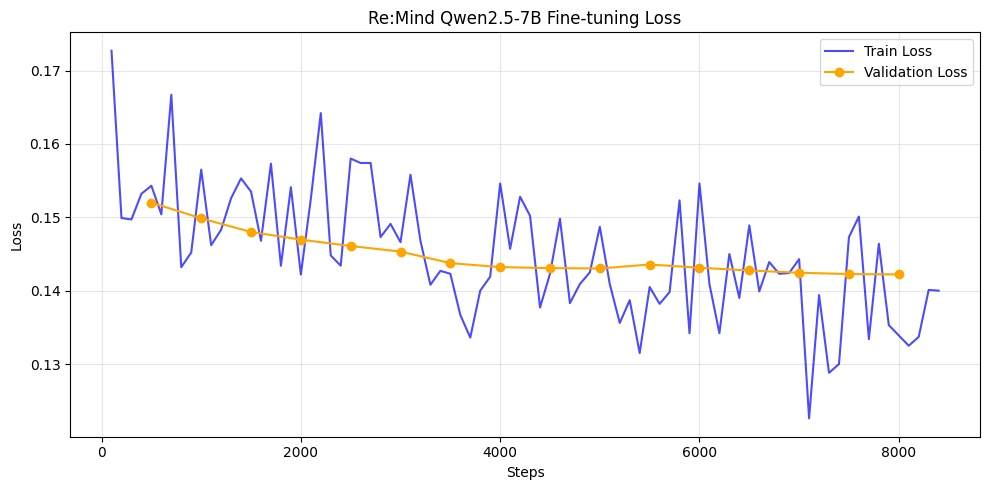

그래프 저장: /content/drive/MyDrive/remind_finetune/training_loss.png


In [17]:
import matplotlib.pyplot as plt

log_history  = trainer.state.log_history
train_steps  = [x['step'] for x in log_history if 'loss' in x and 'eval_loss' not in x]
train_losses = [x['loss'] for x in log_history if 'loss' in x and 'eval_loss' not in x]
eval_steps   = [x['step'] for x in log_history if 'eval_loss' in x]
eval_losses  = [x['eval_loss'] for x in log_history if 'eval_loss' in x]

plt.figure(figsize=(10, 5))
plt.plot(train_steps,  train_losses, label='Train Loss',      color='blue',   alpha=0.7)
plt.plot(eval_steps,   eval_losses,  label='Validation Loss', color='orange', marker='o')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.title('Re:Mind Qwen2.5-7B Fine-tuning Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

graph_path = '/content/drive/MyDrive/remind_finetune/training_loss.png'
plt.savefig(graph_path, dpi=150)
plt.show()
print(f'그래프 저장: {graph_path}')